# 評估目標

::: {.callout-tip}

投影片操作：**Alt + 點擊** 可縮放任何圖片/表格（reveal.js zoom）；`O` 鍵總覽、`F` 全螢幕。

:::

**研究提問**：是否存在「機器學習配對 + 深度學習交易」策略，績效優於 SSD/DTW 距離法基準，且年化報酬 $\ge 2\%$？

資料來源：`results/result.db` `strategy_summaries`（10 策略 × `top_n_list × stop_loss_list` 完整網格）。

> 本筆記本的表格與圖為**執行時動態產生**——result.db 更新後重新執行即得最新比較。


In [1]:
import sqlite3
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib

# 中文字型與大字號（投影片可讀性）
matplotlib.rcParams["font.family"] = ["Microsoft JhengHei", "DejaVu Sans"]
matplotlib.rcParams["axes.unicode_minus"] = False
matplotlib.rcParams.update({"font.size": 14, "figure.dpi": 110})

# 由 notebooks/ 或 repo 根執行皆可
db = next(p / "results" / "result.db" for p in [Path.cwd(), *Path.cwd().parents] if (p / "results" / "result.db").exists())
df = pd.read_sql("SELECT * FROM strategy_summaries", sqlite3.connect(str(db)))
print(f"{db} → {len(df)} 筆網格結果、{df['METHOD'].nunique()} 個策略")


C:\Clark\YZU\Papper\Code\results\result.db → 180 筆網格結果、10 個策略


## 各策略最佳 Sharpe 組合


In [2]:
cols = ["METHOD", "TRADE_METHOD", "TOP N", "STOP LOSS %", "Sharpe_Raw", "Ann_Ret_Raw", "MDD_Raw", "Win_Rate"]
best_sharpe = (df.loc[df.groupby("METHOD")["Sharpe_Raw"].idxmax(), cols]
                 .sort_values("Sharpe_Raw", ascending=False).reset_index(drop=True))
best_sharpe.style.format({"Sharpe_Raw": "{:.3f}", "Ann_Ret_Raw": "{:.2%}", "MDD_Raw": "{:.2%}", "Win_Rate": "{:.1%}"})


,METHOD,TRADE_METHOD,TOP N,STOP LOSS %,Sharpe_Raw,Ann_Ret_Raw,MDD_Raw,Win_Rate
0,SSD-DTW-PCA (Paper-Fixed),Z-Score,Top 3,0%,0.558,2.11%,-9.38%,32.6%
1,HDBSCAN (Cluster-SSD-DTW-PCA-PCA5-DRL-THR),DRL,Top 10,0%,0.460,1.06%,-5.46%,37.4%
2,SSD (Rolling-DRL-THR),DRL,Top 10,0%,0.392,0.82%,-6.26%,35.8%
3,Agglomerative (Fundamentals-DRL-THR),DRL,Top 1,5%,0.348,2.89%,-23.83%,45.4%
4,Agglomerative (Fundamentals),Z-Score,Top 1,15%,0.347,2.17%,-17.17%,35.1%
5,HDBSCAN (Cluster-SSD-DTW-PCA-DRL-THR),DRL,Top 5,0%,0.299,0.72%,-7.74%,38.2%
6,HDBSCAN (Cluster-SSD-DTW-PCA-PCA5),Z-Score,Top 10,0%,0.294,0.90%,-11.69%,33.9%
7,DTW (Paper-Fixed),Z-Score,Top 3,0%,0.271,1.06%,-11.92%,32.8%
8,SSD (Rolling),Z-Score,Top 1,0%,0.262,2.30%,-23.61%,34.4%
9,HDBSCAN (Cluster-SSD-DTW-PCA),Z-Score,Top 5,0%,0.218,0.69%,-19.75%,33.9%


## 各策略最佳年化報酬組合


In [3]:
best_ret = (df.loc[df.groupby("METHOD")["Ann_Ret_Raw"].idxmax(), cols]
              .sort_values("Ann_Ret_Raw", ascending=False).reset_index(drop=True))
best_ret.style.format({"Sharpe_Raw": "{:.3f}", "Ann_Ret_Raw": "{:.2%}", "MDD_Raw": "{:.2%}", "Win_Rate": "{:.1%}"})


,METHOD,TRADE_METHOD,TOP N,STOP LOSS %,Sharpe_Raw,Ann_Ret_Raw,MDD_Raw,Win_Rate
0,Agglomerative (Fundamentals-DRL-THR),DRL,Top 1,5%,0.348,2.89%,-23.83%,45.4%
1,Agglomerative (Fundamentals),Z-Score,Top 1,0%,0.325,2.70%,-23.80%,35.6%
2,SSD (Rolling-DRL-THR),DRL,Top 1,0%,0.277,2.44%,-23.61%,43.0%
3,SSD (Rolling),Z-Score,Top 1,0%,0.262,2.30%,-23.61%,34.4%
4,SSD-DTW-PCA (Paper-Fixed),Z-Score,Top 3,0%,0.558,2.11%,-9.38%,32.6%
5,HDBSCAN (Cluster-SSD-DTW-PCA-DRL-THR),DRL,Top 1,5%,0.268,1.66%,-22.11%,47.1%
6,HDBSCAN (Cluster-SSD-DTW-PCA-PCA5-DRL-THR),DRL,Top 3,0%,0.318,1.16%,-10.43%,38.3%
7,HDBSCAN (Cluster-SSD-DTW-PCA-PCA5),Z-Score,Top 1,15%,0.213,1.08%,-26.38%,33.9%
8,DTW (Paper-Fixed),Z-Score,Top 3,0%,0.271,1.06%,-11.92%,32.8%
9,HDBSCAN (Cluster-SSD-DTW-PCA),Z-Score,Top 1,0%,0.148,0.82%,-30.03%,34.2%


## 最佳 Sharpe 長條圖


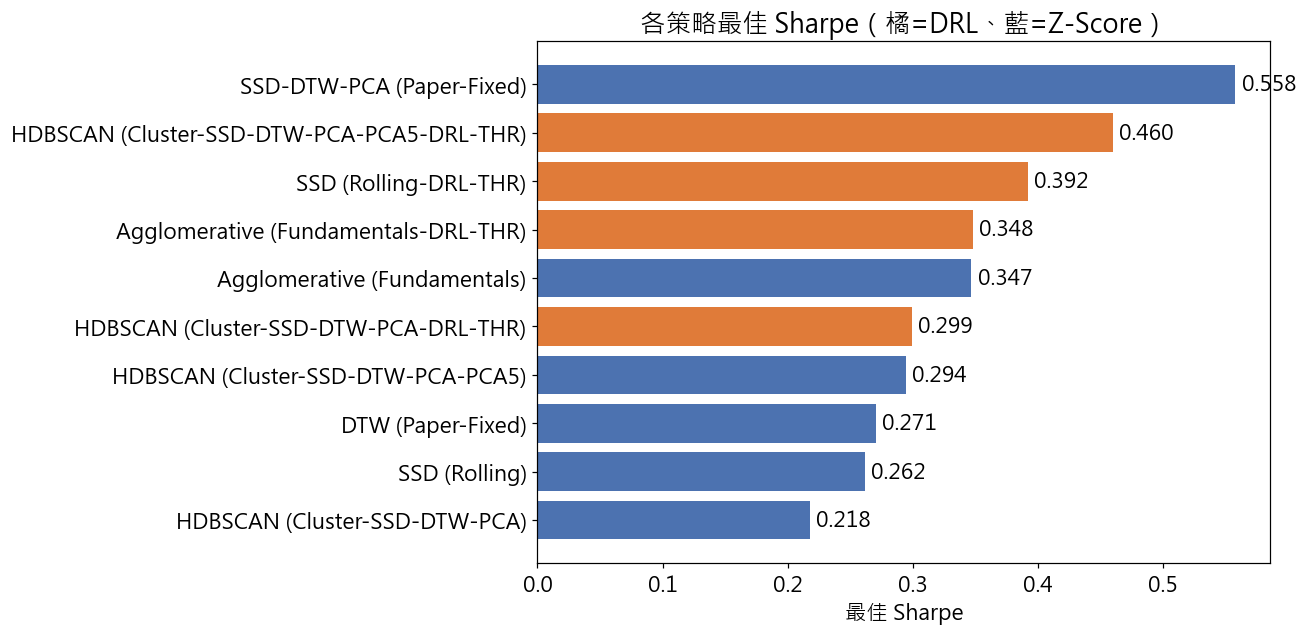

In [4]:
fig, ax = plt.subplots(figsize=(12, 6))
d = best_sharpe.sort_values("Sharpe_Raw")
colors = ["#e07b39" if t == "DRL" else "#4c72b0" for t in d["TRADE_METHOD"]]
ax.barh(d["METHOD"], d["Sharpe_Raw"], color=colors)
ax.set_xlabel("最佳 Sharpe"); ax.set_title("各策略最佳 Sharpe（橘=DRL、藍=Z-Score）")
for i, v in enumerate(d["Sharpe_Raw"]): ax.text(v + 0.005, i, f"{v:.3f}", va="center")
plt.tight_layout(); plt.show()


## 最佳年化報酬長條圖（2% 門檻線）


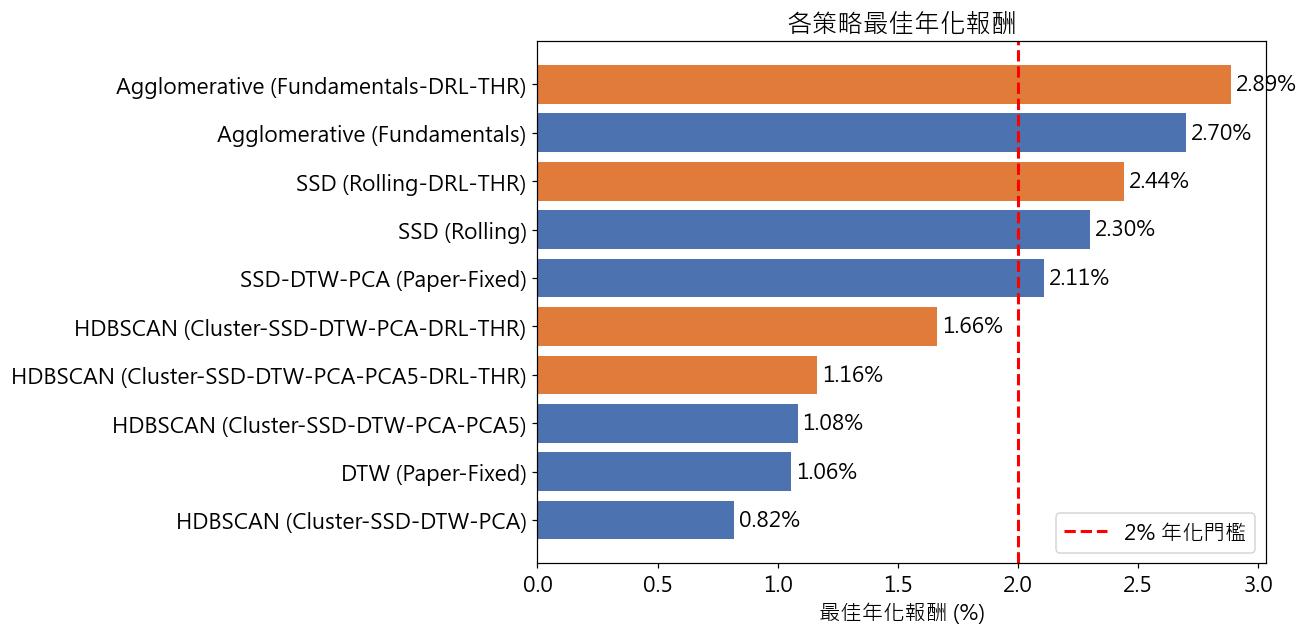

In [5]:
fig, ax = plt.subplots(figsize=(12, 6))
d = best_ret.sort_values("Ann_Ret_Raw")
colors = ["#e07b39" if t == "DRL" else "#4c72b0" for t in d["TRADE_METHOD"]]
ax.barh(d["METHOD"], d["Ann_Ret_Raw"] * 100, color=colors)
ax.axvline(2.0, color="red", ls="--", lw=2, label="2% 年化門檻")
ax.set_xlabel("最佳年化報酬 (%)"); ax.set_title("各策略最佳年化報酬"); ax.legend()
for i, v in enumerate(d["Ann_Ret_Raw"] * 100): ax.text(v + 0.02, i, f"{v:.2f}%", va="center")
plt.tight_layout(); plt.show()


## Sharpe × 年化報酬散佈（全網格）


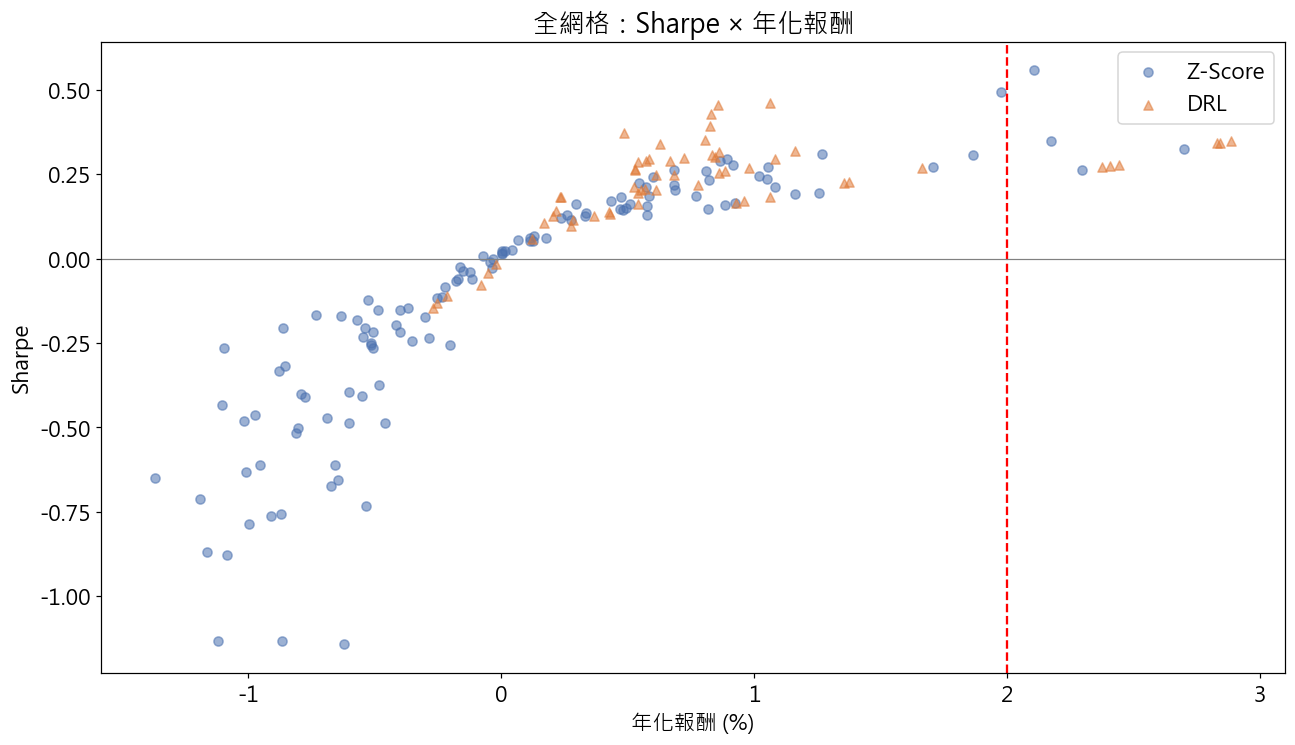

In [6]:
fig, ax = plt.subplots(figsize=(12, 7))
for tm, c, m in [("Z-Score", "#4c72b0", "o"), ("DRL", "#e07b39", "^")]:
    sub = df[df["TRADE_METHOD"] == tm]
    ax.scatter(sub["Ann_Ret_Raw"] * 100, sub["Sharpe_Raw"], c=c, marker=m, alpha=0.55, label=tm)
ax.axvline(2.0, color="red", ls="--", lw=1.5); ax.axhline(0, color="gray", lw=0.8)
ax.set_xlabel("年化報酬 (%)"); ax.set_ylabel("Sharpe"); ax.set_title("全網格：Sharpe × 年化報酬")
ax.legend(); plt.tight_layout(); plt.show()


## Z-Score 基準 vs DRL 疊加（配對比較）


In [7]:
pairs = [("SSD (Rolling)", "SSD (Rolling-DRL-THR)"),
         ("HDBSCAN (Cluster-SSD-DTW-PCA)", "HDBSCAN (Cluster-SSD-DTW-PCA-DRL-THR)"),
         ("HDBSCAN (Cluster-SSD-DTW-PCA-PCA5)", "HDBSCAN (Cluster-SSD-DTW-PCA-PCA5-DRL-THR)"),
         ("Agglomerative (Fundamentals)", "Agglomerative (Fundamentals-DRL-THR)")]
rows = []
for base, drl in pairs:
    bs = df[df["METHOD"] == base]["Sharpe_Raw"].max(); ds = df[df["METHOD"] == drl]["Sharpe_Raw"].max()
    br = df[df["METHOD"] == base]["Ann_Ret_Raw"].max(); dr = df[df["METHOD"] == drl]["Ann_Ret_Raw"].max()
    rows.append({"形成底": base, "Sharpe (Z)": bs, "Sharpe (DRL)": ds, "ΔSharpe": ds - bs,
                 "年化 (Z)": br, "年化 (DRL)": dr, "Δ年化": dr - br})
pd.DataFrame(rows).style.format({"Sharpe (Z)": "{:.3f}", "Sharpe (DRL)": "{:.3f}", "ΔSharpe": "{:+.3f}",
                                  "年化 (Z)": "{:.2%}", "年化 (DRL)": "{:.2%}", "Δ年化": "{:+.2%}"})


,形成底,Sharpe (Z),Sharpe (DRL),ΔSharpe,年化 (Z),年化 (DRL),Δ年化
0,SSD (Rolling),0.262,0.392,+0.130,2.30%,2.44%,+0.14%
1,HDBSCAN (Cluster-SSD-DTW-PCA),0.218,0.299,+0.082,0.82%,1.66%,+0.84%
2,HDBSCAN (Cluster-SSD-DTW-PCA-PCA5),0.294,0.460,+0.166,1.08%,1.16%,+0.08%
3,Agglomerative (Fundamentals),0.347,0.348,+0.001,2.70%,2.89%,+0.19%


## 結論（截至 2026-07-05 數據）{.smaller}

**部分達成研究目標，且有已知前視限制**：

- 5 個策略跨過 2% 年化門檻：Agglomerative DRL THR (2.89%) > Agglomerative (2.70%) > SSD DRL THR (2.44%) > SSD Rolling (2.30%) > SSD-DTW-PCA Fixed (2.11%)
- **Agglomerative Fundamentals 是全組唯一雙指標超越 SSD 基準的 ML 配對**——但受基本面靜態快照前視偏誤限制
- **DRL-THR 能穩定提升風險調整後報酬**（4 組疊加均同向提升 Sharpe），但補不齊年化報酬差距——瓶頸在配對訊號
- **SSD-DTW-PCA (Paper-Fixed) 仍是 Sharpe 最高者（0.56）**：非 ML 的距離法基準尚未被全面超越
- DRL 數值有重訓波動（±0.1 Sharpe 級別，未固定 seed，見 `run_drl_variance.py` 變異數評估）；解讀以相對提升方向為準
